# 1) 
    Duomenų nuskaitymas vyksta per atskirą klasę. Į šį objektą nurdoma vietovės kodas, API URL. Ši klasė turi turėti du metodus:
        a) Istorinių duomenų nuskaitymas už nurodytą laiko intervalą nuo - iki;
        b) Prognozės duomenų nuskaitymas;
    Abiem atvejais duomenys turėtų būti gražinami pandas. DataFrame  formatu, kur indeksas yra laikas (pd.DatetimeIndex) su įvertinta laiko zona;

In [17]:
import requests
import pandas as pd
from datetime import datetime, timedelta

class MeteoLTAPI:
    def __init__(self, place_code, api_url="https://api.meteo.lt"):
        self.place_code = place_code
        self.api_url = api_url
        
    #a) Istorinių duomenų nuskaitymas už nurodytą laiko intervalą nuo - iki
    
    def get_historical_data(self, date_from, date_to, station_code=None):
        """Gauna istorinius duomenis už nurodytą laiko intervalą."""
        code = station_code or self.place_code
        start = datetime.strptime(date_from, '%Y-%m-%d')
        end = datetime.strptime(date_to, '%Y-%m-%d')
        
        all_data = []
        current = start
        while current <= end:
            url = f"{self.api_url}/v1/stations/{code}/observations/{current.strftime('%Y-%m-%d')}"
            try:
                resp = requests.get(url, timeout=10)
                if resp.status_code == 200:
                    data = resp.json().get('observations', [])
                    all_data.extend(data)
            except Exception as e:
                print(f"Klaida nuskaitant {current.date()}: {e}")
            
            current += timedelta(days=1)
        
        if not all_data:
            return pd.DataFrame()
        
        df = pd.DataFrame(all_data)
        df['observationTimeUtc'] = pd.to_datetime(df['observationTimeUtc']).dt.tz_localize('UTC')
        df.set_index('observationTimeUtc', inplace=True)
        df.index.name = 'time'
        return df.sort_index()

    #b) Prognozės duomenų nuskaitymas
    
    def get_forecast_data(self):
        """Gauna prognozės duomenis."""
        url = f"{self.api_url}/v1/places/{self.place_code}/forecasts/long-term"
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code != 200:
                return pd.DataFrame()
            
            data = resp.json().get('forecastTimestamps', [])
            df = pd.DataFrame(data)
            
            # Konvertuojame ir nustatome laiko zoną
            df['forecastTimeUtc'] = pd.to_datetime(df['forecastTimeUtc']).dt.tz_localize('UTC')
            df.set_index('forecastTimeUtc', inplace=True)
            df.index.name = 'time'
            return df
        except Exception as e:
            print(f"Klaida gaunant prognozę: {e}")
            return pd.DataFrame()


# 2) 
    Nuskaičius istorinius duomenis už praeitus metus (laikotarpis nuo šiandien iki metai atgal) suskaičiuoti ir atvaizduoti šiuos rodiklius:
        a) Vidutinė metų temperatūra, oro drėgmė;
        b) Vidutinė metų dienos, ir nakties temperatūra priimant kad skaičiuojama LT laiko zonoje ir diena yra tarp 08:00 ir 20:00;
        c) Kiek savaitgalių (šeštadienis/sekmadienis - 1 savaitgalis) per šį laikotarpį buvo prognozuojama kad lis;

In [18]:
# 1. Sukuriame klasės objektą 
meteo = MeteoLTAPI(place_code='kaunas')

# 2. Pabaigos data – šiandien
date_to = datetime.now().strftime('%Y-%m-%d')

# 3. Pradžios data – lygiai prieš 365 dienas
date_from = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

# 4. Duomenų siuntimas, užtruks porą min, dėl didelio eilučių skaičiaus!
istorija = meteo.get_historical_data(date_from, date_to, 'kauno-ams')

# 5. Rezultato peržiūra
istorija.head()

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode
time,,,,,,,,,,
2025-01-16 00:00:00+00:00,1.5,-1.9,3.2,7.1,283.0,100.0,1030.1,95,0.0,cloudy
2025-01-16 01:00:00+00:00,1.3,-2.0,3.0,6.8,276.0,100.0,1030.1,95,0.0,cloudy
2025-01-16 02:00:00+00:00,1.4,-2.9,4.5,8.1,294.0,100.0,1030.3,96,0.0,cloudy
2025-01-16 03:00:00+00:00,0.9,-2.8,3.5,8.1,292.0,100.0,1030.4,98,0.0,cloudy
2025-01-16 04:00:00+00:00,0.9,-2.0,2.5,7.8,259.0,100.0,1030.3,97,0.0,cloudy


In [19]:
# pasitikrinam paskutinius duomenis, ar data šios dienos
istorija.tail()

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode
time,,,,,,,,,,
2026-01-16 07:00:00+00:00,-15.2,-24.4,5.5,10.4,164.0,100.0,1032.2,81,0.0,light-snow
2026-01-16 08:00:00+00:00,-15.1,-23.8,5.0,7.2,159.0,100.0,1032.8,81,0.0,light-snow
2026-01-16 09:00:00+00:00,-15.0,-25.1,6.8,9.4,153.0,100.0,1033.0,82,0.0,light-snow
2026-01-16 10:00:00+00:00,-14.6,-24.1,6.2,10.5,155.0,100.0,1033.4,81,0.0,light-snow
2026-01-16 11:00:00+00:00,-14.1,-24.0,6.9,10.9,151.0,13.0,1033.1,77,0.0,light-snow


In [20]:
# Išsami statistinė santrauka. Pagal "count" eilutę matome, kad kai kuriuose stulpeliuose trūksta duomenų, į tai reiks atsižvelgti vėliau.
istorija.describe(include='all')

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode
count,8772.000000,8705.000000,8705.000000,8666.000000,8705.000000,8637.000000,8772.000000,8772.000000,8772.000000,8767
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cloudy
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3638
mean,8.359029,6.604813,3.309087,6.228191,206.835497,64.728957,1015.553853,78.644095,0.059656,NaN
std,8.529229,10.106191,1.710509,3.038793,94.672043,41.737122,8.965471,16.459147,0.437832,NaN
min,-18.100000,-25.200000,0.100000,0.600000,0.000000,0.000000,984.300000,23.000000,0.000000,NaN
25%,2.000000,-1.000000,2.000000,3.900000,152.000000,13.000000,1010.175000,69.000000,0.000000,NaN
50%,8.000000,6.200000,3.100000,6.000000,212.000000,88.000000,1015.700000,84.000000,0.000000,NaN
75%,15.200000,15.100000,4.400000,8.200000,285.000000,100.000000,1020.400000,92.000000,0.000000,NaN


# 2.a 
    Vidutinė metų temperatūra, oro drėgmė;

In [21]:
# a) Vidutinės metų temperatūros ir drėgmės skaičiavimas
vidutine_temp = istorija['airTemperature'].mean()
vidutine_dregme = istorija['relativeHumidity'].mean()

print(f"Vidutinė metų temperatūra: {vidutine_temp:.2f} °C")
print(f"Vidutinė metų oro drėgmė: {vidutine_dregme:.2f} %")

Vidutinė metų temperatūra: 8.36 °C
Vidutinė metų oro drėgmė: 78.64 %


# 2.b 
    Vidutinė metų dienos, ir nakties temperatūra priimant kad skaičiuojama LT laiko zonoje ir diena yra tarp 08:00 ir 20:00;

In [22]:
# Svarbu: konvertuojame indeksą į Lietuvos laiko zoną
istorija.index = istorija.index.tz_convert('Europe/Vilnius')

# Pasitikrinam laiko formatą
istorija.head(3)

,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,conditionCode
time,,,,,,,,,,
2025-01-16 02:00:00+02:00,1.5,-1.9,3.2,7.1,283.0,100.0,1030.1,95,0.0,cloudy
2025-01-16 03:00:00+02:00,1.3,-2.0,3.0,6.8,276.0,100.0,1030.1,95,0.0,cloudy
2025-01-16 04:00:00+02:00,1.4,-2.9,4.5,8.1,294.0,100.0,1030.3,96,0.0,cloudy


In [23]:
# Diena: nuo 08:00 (įskaitytinai) iki 20:00 (neįskaitytinai, t.y. iki 19:59)
diena_mask = (istorija.index.hour >= 8) & (istorija.index.hour < 20)

diena_df = istorija[diena_mask]
naktis_df = istorija[~diena_mask] # Viskas, kas ne diena, yra naktis

vid_diena = diena_df['airTemperature'].mean()
vid_naktis = naktis_df['airTemperature'].mean()

print(f"Vidutinė metų dienos temperatūra (08-20 val.): {vid_diena:.2f} °C")
print(f"Vidutinė metų nakties temperatūra: {vid_naktis:.2f} °C")

Vidutinė metų dienos temperatūra (08-20 val.): 9.85 °C
Vidutinė metų nakties temperatūra: 6.87 °C


# 2.c 
    Kiek savaitgalių (šeštadienis/sekmadienis - 1 savaitgalis) per šį laikotarpį buvo prognozuojama kad lis;

In [24]:
# matome, kad "conditionCode" stulpelis turi 5 "NaN" reikšmes
print(istorija.isna().sum())

airTemperature            0
feelsLikeTemperature     67
windSpeed                67
windGust                106
windDirection            67
cloudCover              135
seaLevelPressure          0
relativeHumidity          0
precipitation             0
conditionCode             5
dtype: int64


In [28]:
# 2. Išfiltruojame tik šeštadienius (5) ir sekmadienius (6)
savaitgaliai = istorija[istorija.index.weekday.isin([5, 6])]

# 3. Surandame visas valandas, kai lijo (ieškome "rain" tekste)
# na=False užtikrina, kad jei yra NaN reikšmių, jos nesugadins kodo
lietingos_valandos = savaitgaliai[savaitgaliai['conditionCode'].str.contains('rain', na=False)]

# 4. Sugrupuojame pagal savaites, kad 1 savaitgalis būtų skaičiuojamas kaip 1 vienetas
# %G-V formatas užtikrina teisingą metų ir savaitės numerį (ISO savaitė)
lietingi_savaitgaliai_count = lietingos_valandos.index.strftime('%G-%V').nunique() 
#strftime('%G-%V'): Kiekvieną datą paverčia į tekstą, nurodantį metus ir savaitės numerį (pvz., „2024-02“, „2024-45“).
#.nunique(): Suskaičiuoja, kiek skirtingų (unikalių) savaitės kodų gavosi. Jei per tą patį savaitgalį lijo 10 kartų, nunique jį užskaitys kaip 1 vienetą, nes kodas buvo tas pats.

print(f"Savaitgalių skaičius, buvo prognozuojama kad lis: {lietingi_savaitgaliai_count}")

Savaitgalių skaičius, buvo prognozuojama kad lis: 41


# 3) 
    Nuskaičius prognozės duomenis juos apjungti su istoriniais. Atvaizduoti grafiką, kuris rodo paskutinės savaitės išmatuotą temperatūrą ir ateinančio periodo prognozuojama temperatūrą.

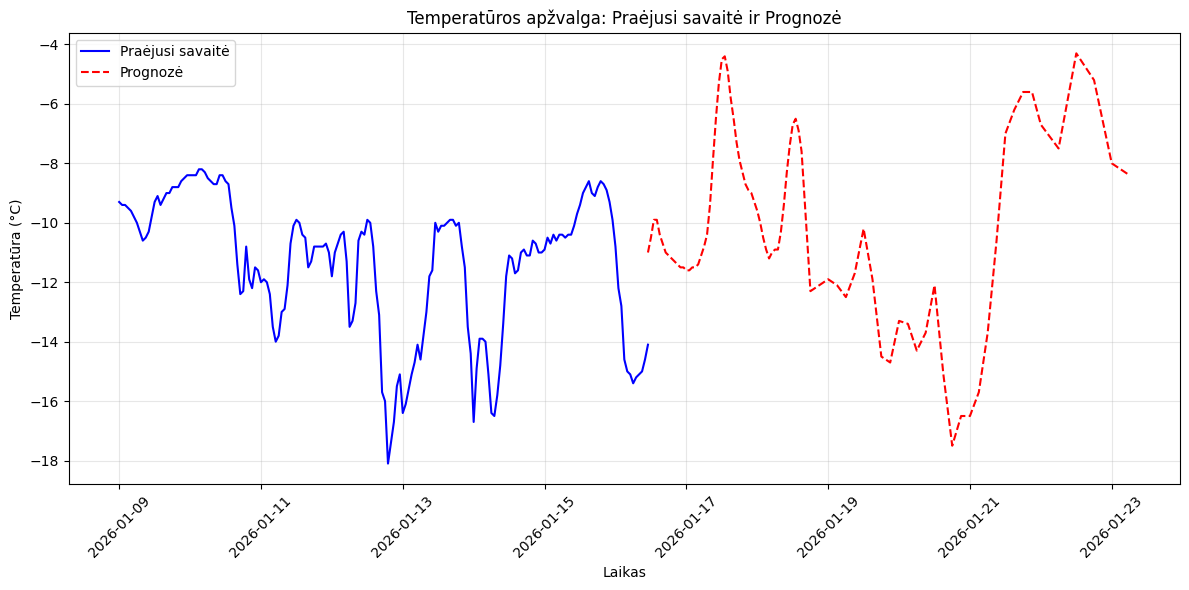

In [26]:
import matplotlib.pyplot as plt

# --- 1. Gauname paskutinės savaitės istoriją ---
date_to = datetime.now().strftime('%Y-%m-%d')
date_from = (datetime.now() - timedelta(days=7)).strftime('%Y-%m-%d')
istorija_savaitė = meteo.get_historical_data(date_from, date_to, 'kauno-ams')

# --- 2. Gauname prognozę ---
prognoze = meteo.get_forecast_data()

# --- 3. Suvienodiname laiko zonas ir stulpelius ---
# Užtikriname, kad abu naudoja tą patį pavadinimą temperatūrai atvaizduoti
hist_plot = istorija_savaitė[['airTemperature']].copy()
fore_plot = prognoze[['airTemperature']].copy()

# Pervadiname, kad būtų aiškiau grafike
hist_plot.columns = ['Faktinė Temp']
fore_plot.columns = ['Prognozuojama Temp']

# --- 4. Braižome grafiką ---
plt.figure(figsize=(12, 6))

# Braižome istoriją
plt.plot(hist_plot.index, hist_plot['Faktinė Temp'], label='Praėjusi savaitė', color='blue')

# Braižome prognozę
plt.plot(fore_plot.index, fore_plot['Prognozuojama Temp'], label='Prognozė', color='red', linestyle='--')

# Grafiko apipavidalinimas
plt.title('Temperatūros apžvalga: Praėjusi savaitė ir Prognozė')
plt.xlabel('Laikas')
plt.ylabel('Temperatūra (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 4) 
    Visi nuskaityti duomenys yra valandiniai. Parašyti funkciją, į kurią padavus temperatūros pandas. Series suskaičiuotų tarpines reikšmes ir pagražintų rezultatą pandas. Series kurio dažnis yra 5 minutės. Tarpines reikšmes interpoliuoti.

In [27]:
def interpoliuoti_temperatura(serija):
    """
    Padidina Series dažnį iki 5 minučių ir interpoliuoja reikšmes.
    """
    # 1. Pakeičiame dažnį į 5 minutes ('5min')
    # Resample sukuria naujus laiko taškus, bet jų reikšmės bus NaN
    rezultatas = serija.resample('5min').asfreq()
    
    # 2. Interpoliuojame (naudojame 'linear' arba 'time' metodą)
    # 'time' metodas geriausiai tinka laiko eilutėms
    rezultatas = rezultatas.interpolate(method='time')
    
    return rezultatas

# --- PAVYZDYS ---
# Paimame paskutines 24 valandas iš tavo turimos istorijos
paskutine_para = istorija.tail(24)['airTemperature']

# Iškviečiame funkciją
interpoliuoti_duomenys = interpoliuoti_temperatura(paskutine_para)

# Patikriname rezultatą
print(f"Originalių duomenų kiekis: {len(paskutine_para)}")
print(f"Interpoliuotų duomenų kiekis: {len(interpoliuoti_duomenys)}")
print(interpoliuoti_duomenys.head(15)) # Matysime valandą suskaidytą kas 5 min.


Originalių duomenų kiekis: 24
Interpoliuotų duomenų kiekis: 277
time
2026-01-15 14:00:00+02:00   -9.400000
2026-01-15 14:05:00+02:00   -9.366667
2026-01-15 14:10:00+02:00   -9.333333
2026-01-15 14:15:00+02:00   -9.300000
2026-01-15 14:20:00+02:00   -9.266667
2026-01-15 14:25:00+02:00   -9.233333
2026-01-15 14:30:00+02:00   -9.200000
2026-01-15 14:35:00+02:00   -9.166667
2026-01-15 14:40:00+02:00   -9.133333
2026-01-15 14:45:00+02:00   -9.100000
2026-01-15 14:50:00+02:00   -9.066667
2026-01-15 14:55:00+02:00   -9.033333
2026-01-15 15:00:00+02:00   -9.000000
2026-01-15 15:05:00+02:00   -8.983333
2026-01-15 15:10:00+02:00   -8.966667
Freq: 5min, Name: airTemperature, dtype: float64
